In [ ]:
import numpy as np
import pandas as pd
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Proj
from matplotlib.ticker import MultipleLocator

BASE_DIR = os.getcwd()
WINDOW_SIZE = 200

DATA_CONFIG = {
    "looking_left05.csv": {"skiprows": 300, "flag": True, "zone": 52},
    "looking_right04.csv": {"skiprows": 350, "flag": True, "zone": 52},
}

DATA_FILE_PATH_LIST = [
    # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left05.csv"), # 2분 
    os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_right04.csv"), # 2분 
    #os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l03.csv"),
]

In [ ]:
class DataProcessor:
    def __init__(self, window_size, stride):
        self.window_size = window_size
        self.stride = stride
        
    def data_load(self, file_path, skiprows, skipfooter, flag):
        if flag:
            df = pd.read_csv(
                file_path,
                skiprows=skiprows,
                skipfooter=skipfooter,
                na_values=["", "nan", "NaN"],
                engine="python"
            ).fillna(0)
            
        else:
            df = pd.read_csv(
                file_path,
                skiprows=skiprows,
                skipfooter=skipfooter,
                engine="python"
            )
            
        df.columns = [
            "Timestamp",
            "Acc_x", "Acc_y", "Acc_z",
            "Gyro_x", "Gyro_y", "Gyro_z",
            "Mag_x", "Mag_y", "Mag_z",
            "Ori_x", "Ori_y", "Ori_z",
            "Pressure",
            "Latitude", "Longitude", "Altitude", "Speed_GPS"
        ]
        
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y-%m-%d %H:%M:%S.%f")
        start_dt = df["Timestamp"].iloc[0]
        df["Elapsed Time"] = (df["Timestamp"] - start_dt).dt.total_seconds()
        
        # GPS가 있는 행만 선택
        valid_gps_mask = (
            df["Latitude"].notna() &
            df["Longitude"].notna() &
            (df["Latitude"].astype(str).str.strip() != "") &
            (df["Longitude"].astype(str).str.strip() != "")
        )

        filtered_lat = pd.to_numeric(df.loc[valid_gps_mask, "Latitude"], errors="coerce").values
        filtered_lon = pd.to_numeric(df.loc[valid_gps_mask, "Longitude"], errors="coerce").values
        
        proj_enu = Proj(proj="utm", zone=52, ellps="WGS84", south=False)
        e0, n0 = proj_enu(filtered_lon[0], filtered_lat[0])
        e, n = proj_enu(filtered_lon, filtered_lat)

        e = e - e0
        n = n - n0
        
        return df, e, n

In [ ]:
DataProcessor = DataProcessor(window_size=WINDOW_SIZE, stride=5)

df1, df1_e, df1_n = DataProcessor.data_load(
    file_path=DATA_FILE_PATH_LIST[0],
    skiprows=DATA_CONFIG["looking_left05.csv"]["skiprows"],
    skipfooter=0,
    flag=DATA_CONFIG["looking_left05.csv"]["flag"]
)

plt.plot(df1_e, df1_n, '.-')
plt.grid()
plt.axis("equal")
plt.xlabel("E (m)")
plt.ylabel("N (m)")
plt.show()

# 1. 차분 (속도 방향)
dE = np.diff(df1_e)
dN = np.diff(df1_n)

# 2. heading (rad)
heading = np.arctan2(dE, dN)

# 3. degree로 변환 (선택)
heading_deg = np.degrees(heading)

heading_unwrapped = np.unwrap(heading)
heading_unwrapped_deg = np.degrees(heading_unwrapped)
# rad 기준
dh = np.diff(heading_unwrapped)

# deg 기준
dh_deg = np.degrees(dh)


plt.plot(heading_deg)
plt.grid()
plt.show()

plt.plot(dh_deg)
plt.grid()
plt.show()

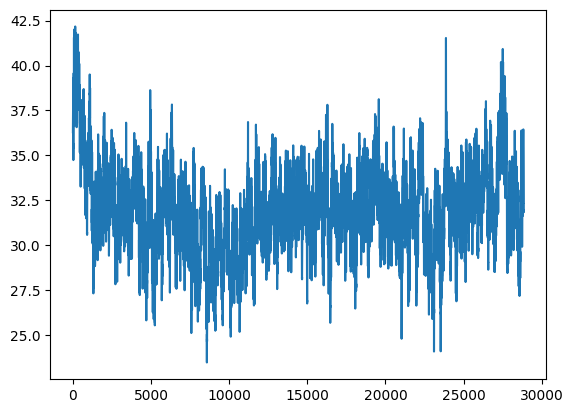

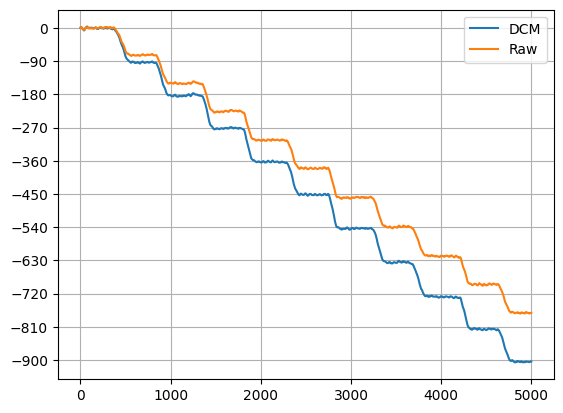

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0. sampling
# =========================
fs = 50.0
dt = 1.0 / fs

# =========================
# 1. gyro 불러오기
# =========================
gx = df1["Gyro_x"].to_numpy().astype(float)
gy = df1["Gyro_y"].to_numpy().astype(float)
gz = df1["Gyro_z"].to_numpy().astype(float)



# =========================
# 2. GameRotationVector (x, y, z)
# =========================
qx = df1["Ori_x"].to_numpy().astype(float).copy()
qy = df1["Ori_y"].to_numpy().astype(float).copy()
qz = df1["Ori_z"].to_numpy().astype(float).copy()

# =========================
# 3. qw 복원
# =========================
qw_sq = 1.0 - (qx**2 + qy**2 + qz**2)
qw_sq = np.clip(qw_sq, 0.0, None)
qw = np.sqrt(qw_sq)

# =========================
# 4. 쿼터니언 부호 연속성 보정
# =========================
for i in range(1, len(qw)):
    dot = (
        qw[i-1] * qw[i]
        + qx[i-1] * qx[i]
        + qy[i-1] * qy[i]
        + qz[i-1] * qz[i]
    )
    if dot < 0:
        qw[i] = -qw[i]
        qx[i] = -qx[i]
        qy[i] = -qy[i]
        qz[i] = -qz[i]

# =========================
# 5. pitch 계산
# =========================
pitch = np.arctan2(
    2.0 * (qw * qx + qy * qz),
    1.0 - 2.0 * (qx * qx + qy * qy)
)

pitch_deg = np.degrees(pitch)

# =========================
# 6. pitch 제거하여 gyro 보정
# y축 회전 inverse 적용
# =========================
gyro_corr = np.zeros((len(gx), 3))

for i in range(len(gx)):
    c = np.cos(pitch[i])
    s = np.sin(pitch[i])

    R_inv_pitch = np.array([
        [ 1,  0, 0],
        [ 0,  c,  -s],
        [ 0,  s,  c]
    ])

    g = np.array([gx[i], gy[i], gz[i]])
    gyro_corr[i] = R_inv_pitch @ g

gx_corr = gyro_corr[:, 0]
gy_corr = gyro_corr[:, 1]
gz_corr = gyro_corr[:, 2]

theta_z = np.cumsum(gz_corr) * dt

theta_z_deg = np.degrees(theta_z)

plt.plot(pitch_deg)
plt.show()

raw_heading = np.cumsum(gz) * 0.02
plt.plot(theta_z_deg[:5000], label="DCM")
plt.plot(np.degrees(raw_heading[:5000]), label="Raw")
plt.grid()
plt.gca().yaxis.set_major_locator(MultipleLocator(90))
plt.legend()
plt.show()

In [13]:
heading_diff_deg = np.diff(theta_z_deg)

print(np.sum(heading_diff_deg[800:1000]))

-90.91104505269763
